In [1]:
pip install pymorphy3

In [1]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string

import re
import nltk
import pymorphy3

from nltk.stem.snowball import SnowballStemmer

In [2]:
df = pd.read_csv('kinopoisk.csv')

In [3]:
df.head()

,rating,movie,year,country,rating_ball,overview,director,screenwriter,actors,url_logo
0,0,Побег из Шоушенка,1994,США,9.111,Бухгалтер Энди Дюфрейн обвинён в убийстве собс...,Фрэнк Дарабонт,Фрэнк Дарабонт; Стивен Кинг,Тим Роббинс; Морган Фриман; Боб Гантон; Уильям...,'https://st.kp.yandex.net/images/film_iphone/i...
1,1,Зеленая миля,1999,США,9.062,Пол Эджкомб — начальник блока смертников в тюр...,Фрэнк Дарабонт,Фрэнк Дарабонт; Стивен Кинг,Том Хэнкс; Дэвид Морс; Бонни Хант; Майкл Кларк...,'https://st.kp.yandex.net/images/film_iphone/i...
2,2,Форрест Гамп,1994,США,8.913,От лица главного героя Форреста Гампа; слабоум...,Роберт Земекис,Эрик Рот; Уинстон Грум,Том Хэнкс; Робин Райт; Салли Филд; Гэри Синиз;...,'https://st.kp.yandex.net/images/film_iphone/i...
3,3,Список Шиндлера,1993,США,8.817,Фильм рассказывает реальную историю загадочног...,Стивен Спилберг,Стивен Зеллиан; Томас Кенилли,Лиам Нисон; Бен Кингсли; Рэйф Файнс; Кэролайн ...,'https://st.kp.yandex.net/images/film_iphone/i...
4,4,1+1,2011,Франция,8.807,Пострадав в результате несчастного случая; бог...,Оливье Накаш; Эрик Толедано,Оливье Накаш; Филипп Поццо ди Борго; Эрик Т...,Франсуа Клюзе; Омар Си; Анн Ле Ни; Одри Флеро;...,'https://st.kp.yandex.net/images/film_iphone/i...


In [4]:
janr = ['драма', 'драма, фэнтези, криминал','драма, комедия, мелодрама, история, военный', 'драма, биография, история, военный','драма, комедия','фантастика, боевик, триллер, драма, детектив', 'боевик, триллер, драма, криминал',
        'мультфильм, мюзикл, драма, приключения, семейный','триллер, драма, криминал','комедия, фантастика, приключения','военный, комедия, драма, мелодрама',
        'драма, комедия, криминал','драма, криминал','криминал, драма','комедия, мелодрама, криминал','триллер, фантастика, драма, детектив',
        'биография, драма, мелодрама','фантастика, драма, приключения','фэнтези, приключения, драма, боевик','история, боевик, драма','фантастика, комедия, приключения', 
        'боевик, комедия, криминал','фантастика, боевик','комедия, криминал','криминал, драма, триллер','криминал, биография, комедия','драма, военный, биография, музыка',
        'фэнтези, приключения, драма, боевик','военный, драма, комедия','мультфильм, фантастика, приключения, семейный','мультфильм, фэнтези, комедия, приключения, семейный, музыка',
        'криминал, комедия, боевик','фэнтези, приключения, драма, боевик','драма, криминал','комедия, драма, криминал, детектив',
        'фэнтези, боевик, приключения','триллер, детектив, драма','фантастика, боевик, триллер, криминал, драма','драма','мелодрама, история, триллер, драма',
        'драма, детектив, криминал','драма','драма, фантастика','мелодрама, комедия, криминал, музыка','драма, семейный, биография',
        'комедия, мелодрама, драма','аниме, мультфильм, фэнтези, приключения, семейный','комедия, приключения, мелодрама, мюзикл','драма, военный, история',
        'фэнтези, драма, мелодрама, семейный']

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   rating        250 non-null    int64  
 1   movie         250 non-null    object 
 2   year          250 non-null    int64  
 3   country       250 non-null    object 
 4   rating_ball   250 non-null    float64
 5   overview      250 non-null    object 
 6   director      250 non-null    object 
 7   screenwriter  250 non-null    object 
 8   actors        250 non-null    object 
 9   url_logo      250 non-null    object 
dtypes: float64(1), int64(2), object(7)
memory usage: 19.7+ KB


In [6]:
df['overview'][0]

'Бухгалтер Энди Дюфрейн обвинён в\xa0убийстве собственной жены и\xa0её любовника. Оказавшись в\xa0тюрьме под\xa0названием Шоушенк; он\xa0сталкивается с\xa0жестокостью и\xa0беззаконием; царящими по\xa0обе стороны решётки. Каждый; кто\xa0попадает в\xa0эти стены; становится их\xa0рабом до\xa0конца жизни. Но\xa0Энди; обладающий живым умом и\xa0доброй душой; находит подход как\xa0к заключённым; так\xa0и к\xa0охранникам; добиваясь их\xa0особого к\xa0себе расположения.'

In [7]:
df['overview'][200]

'В легендах и\xa0мифах есть персонажи; главная задача которых\xa0—\xa0исполнять желания. У\xa0арабов это\xa0—\xa0джинны; у\xa0ирландцев\xa0—\xa0лепреконы; у\xa0китайцев\xa0—\xa0драконы; у\xa0европейцев\xa0—\xa0феи и\xa0лесные духи. А\xa0в Америке есть некто О.\xa0Ж. Грант\xa0—\xa0довольно странный и\xa0забавный человек; который тоже может исполнить любое желание. Но\xa0будьте осторожны; он\xa0очень проказлив! Вот\xa0его-то и\xa0встречает однажды Нил\xa0Оливер.Нил вполне доволен своей жизнью: у\xa0него обеспеченные родители; симпатичная невеста и\xa0впереди блестящая карьера юриста. Но\xa0с недавних пор\xa0по ночам ему\xa0стала сниться загадочная девушка; которую он\xa0никак не\xa0может выбросить из\xa0головы.Чудаковатый Грант приглашает Нила совершить поездку по\xa0таинственной автостраде 60; которой нет\xa0ни на\xa0одной карте США. И\xa0Нил бросает всё и\xa0пускается в\xa0самое невероятное и\xa0рискованное путешествие в\xa0своей жизни; решив во\xa0что бы\xa0то ни\xa0стало разыскать не

In [8]:
st = '\xa0—'
def remove_othersymbol(text):
    return ''.join([ch if ch not in st else ' ' for ch in text])

In [9]:
df['prep_text']= [remove_othersymbol(text.lower()) for text in df['overview']]

In [10]:
df['prep_text'][0]

'бухгалтер энди дюфрейн обвинён в убийстве собственной жены и её любовника. оказавшись в тюрьме под названием шоушенк; он сталкивается с жестокостью и беззаконием; царящими по обе стороны решётки. каждый; кто попадает в эти стены; становится их рабом до конца жизни. но энди; обладающий живым умом и доброй душой; находит подход как к заключённым; так и к охранникам; добиваясь их особого к себе расположения.'

In [11]:
df['prep_text'][200]

'в легендах и мифах есть персонажи; главная задача которых   исполнять желания. у арабов это   джинны; у ирландцев   лепреконы; у китайцев   драконы; у европейцев   феи и лесные духи. а в америке есть некто о. ж. грант   довольно странный и забавный человек; который тоже может исполнить любое желание. но будьте осторожны; он очень проказлив! вот его-то и встречает однажды нил оливер.нил вполне доволен своей жизнью: у него обеспеченные родители; симпатичная невеста и впереди блестящая карьера юриста. но с недавних пор по ночам ему стала сниться загадочная девушка; которую он никак не может выбросить из головы.чудаковатый грант приглашает нила совершить поездку по таинственной автостраде 60; которой нет ни на одной карте сша. и нил бросает всё и пускается в самое невероятное и рискованное путешествие в своей жизни; решив во что бы то ни стало разыскать незнакомку из своих снов.'

In [12]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [13]:
def remove_punctuation(text):
    return ''.join([ch for ch in text if ch not in string.punctuation])

In [14]:
df['prep_text']= [remove_punctuation(text) for text in df['prep_text']]

In [15]:
df['prep_text'][0]

'бухгалтер энди дюфрейн обвинён в убийстве собственной жены и её любовника оказавшись в тюрьме под названием шоушенк он сталкивается с жестокостью и беззаконием царящими по обе стороны решётки каждый кто попадает в эти стены становится их рабом до конца жизни но энди обладающий живым умом и доброй душой находит подход как к заключённым так и к охранникам добиваясь их особого к себе расположения'

In [16]:
df['prep_text'][200]

'в легендах и мифах есть персонажи главная задача которых   исполнять желания у арабов это   джинны у ирландцев   лепреконы у китайцев   драконы у европейцев   феи и лесные духи а в америке есть некто о ж грант   довольно странный и забавный человек который тоже может исполнить любое желание но будьте осторожны он очень проказлив вот егото и встречает однажды нил оливернил вполне доволен своей жизнью у него обеспеченные родители симпатичная невеста и впереди блестящая карьера юриста но с недавних пор по ночам ему стала сниться загадочная девушка которую он никак не может выбросить из головычудаковатый грант приглашает нила совершить поездку по таинственной автостраде 60 которой нет ни на одной карте сша и нил бросает всё и пускается в самое невероятное и рискованное путешествие в своей жизни решив во что бы то ни стало разыскать незнакомку из своих снов'

In [17]:
def remove_latin(text):
    return re.sub('[a-z]','', text, flags=re.I)

In [18]:
df.head()

,rating,movie,year,country,rating_ball,overview,director,screenwriter,actors,url_logo,prep_text
0,0,Побег из Шоушенка,1994,США,9.111,Бухгалтер Энди Дюфрейн обвинён в убийстве собс...,Фрэнк Дарабонт,Фрэнк Дарабонт; Стивен Кинг,Тим Роббинс; Морган Фриман; Боб Гантон; Уильям...,'https://st.kp.yandex.net/images/film_iphone/i...,бухгалтер энди дюфрейн обвинён в убийстве собс...
1,1,Зеленая миля,1999,США,9.062,Пол Эджкомб — начальник блока смертников в тюр...,Фрэнк Дарабонт,Фрэнк Дарабонт; Стивен Кинг,Том Хэнкс; Дэвид Морс; Бонни Хант; Майкл Кларк...,'https://st.kp.yandex.net/images/film_iphone/i...,пол эджкомб начальник блока смертников в тюр...
2,2,Форрест Гамп,1994,США,8.913,От лица главного героя Форреста Гампа; слабоум...,Роберт Земекис,Эрик Рот; Уинстон Грум,Том Хэнкс; Робин Райт; Салли Филд; Гэри Синиз;...,'https://st.kp.yandex.net/images/film_iphone/i...,от лица главного героя форреста гампа слабоумн...
3,3,Список Шиндлера,1993,США,8.817,Фильм рассказывает реальную историю загадочног...,Стивен Спилберг,Стивен Зеллиан; Томас Кенилли,Лиам Нисон; Бен Кингсли; Рэйф Файнс; Кэролайн ...,'https://st.kp.yandex.net/images/film_iphone/i...,фильм рассказывает реальную историю загадочног...
4,4,1+1,2011,Франция,8.807,Пострадав в результате несчастного случая; бог...,Оливье Накаш; Эрик Толедано,Оливье Накаш; Филипп Поццо ди Борго; Эрик Т...,Франсуа Клюзе; Омар Си; Анн Ле Ни; Одри Флеро;...,'https://st.kp.yandex.net/images/film_iphone/i...,пострадав в результате несчастного случая бога...


In [19]:
russian_stopwords = stopwords.words("russian") 

In [20]:
russian_stopwords.extend(['т.д.', 'т', 'д', 'это','который','свой','своём','всем','всё','её','оба','ещё','должный']) 

In [21]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\МОиБД\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [22]:
morph = pymorphy3.MorphAnalyzer(lang='ru')

In [23]:
%%time
lemm_texts_list = []
for text in (df['prep_text']):
    try:
        tokens = word_tokenize(text)
        res = list()
        for word in tokens:
            p = morph.parse(word)[0]
            res.append(p.normal_form)
        text = " ".join(res)
        lemm_texts_list.append(text)
    except Exception as e:
        print(e)
    
df['text_lemm'] = lemm_texts_list

CPU times: total: 2.3 s
Wall time: 2.33 s


In [24]:
df.head()

,rating,movie,year,country,rating_ball,overview,director,screenwriter,actors,url_logo,prep_text,text_lemm
0,0,Побег из Шоушенка,1994,США,9.111,Бухгалтер Энди Дюфрейн обвинён в убийстве собс...,Фрэнк Дарабонт,Фрэнк Дарабонт; Стивен Кинг,Тим Роббинс; Морган Фриман; Боб Гантон; Уильям...,'https://st.kp.yandex.net/images/film_iphone/i...,бухгалтер энди дюфрейн обвинён в убийстве собс...,бухгалтер энди дюфрейн обвинить в убийство соб...
1,1,Зеленая миля,1999,США,9.062,Пол Эджкомб — начальник блока смертников в тюр...,Фрэнк Дарабонт,Фрэнк Дарабонт; Стивен Кинг,Том Хэнкс; Дэвид Морс; Бонни Хант; Майкл Кларк...,'https://st.kp.yandex.net/images/film_iphone/i...,пол эджкомб начальник блока смертников в тюр...,пол эджкомба начальник блок смертник в тюрьма ...
2,2,Форрест Гамп,1994,США,8.913,От лица главного героя Форреста Гампа; слабоум...,Роберт Земекис,Эрик Рот; Уинстон Грум,Том Хэнкс; Робин Райт; Салли Филд; Гэри Синиз;...,'https://st.kp.yandex.net/images/film_iphone/i...,от лица главного героя форреста гампа слабоумн...,от лицо главное герой форрест гампа слабоумный...
3,3,Список Шиндлера,1993,США,8.817,Фильм рассказывает реальную историю загадочног...,Стивен Спилберг,Стивен Зеллиан; Томас Кенилли,Лиам Нисон; Бен Кингсли; Рэйф Файнс; Кэролайн ...,'https://st.kp.yandex.net/images/film_iphone/i...,фильм рассказывает реальную историю загадочног...,фильм рассказывать реальный история загадочный...
4,4,1+1,2011,Франция,8.807,Пострадав в результате несчастного случая; бог...,Оливье Накаш; Эрик Толедано,Оливье Накаш; Филипп Поццо ди Борго; Эрик Т...,Франсуа Клюзе; Омар Си; Анн Ле Ни; Одри Флеро;...,'https://st.kp.yandex.net/images/film_iphone/i...,пострадав в результате несчастного случая бога...,пострадать в результат несчастный случай богат...


In [25]:
df['text_lemm'][0]

'бухгалтер энди дюфрейн обвинить в убийство собственный жена и её любовник оказаться в тюрьма под название шоушенк он сталкиваться с жестокость и беззаконие царить по оба сторона решётка каждый кто попадать в этот стена становиться они раб до конец жизнь но энди обладать живой ум и добрый душа находить подход как к заключить так и к охранник добиваться они особый к себя расположение'

In [26]:
df['text_lemm'][200]

'в легенда и миф есть персонаж главный задача который исполнять желание у араб это джинн у ирландец лепрекон у китаец дракон у европеец фея и лесной дух а в америка есть некто о ж грант довольно странный и забавный человек который тоже мочь исполнить любой желание но быть осторожный он очень проказливый вот еготь и встречать однажды нил оливернить вполне довольный свой жизнь у он обеспечить родитель симпатичный невеста и впереди блестящий карьера юрист но с недавний пора по ночь он стать сниться загадочный девушка который он никак не мочь выбросить из головычудаковатый грант приглашать нил совершить поездка по таинственный автострада 60 который нет ни на один карта сша и нил бросать всё и пускаться в самый невероятный и рискованный путешествие в свой жизнь решить в что бы то ни стать разыскать незнакомка из свой сон'

In [27]:
def tokenize(text):
    t = word_tokenize(text)
    tokens = [token for token in t if token not in russian_stopwords]
    text = " ".join(tokens)
    return text

In [28]:
df['tokenize_text'] = [tokenize(text) for text in df['text_lemm']]

In [29]:
df.head()

,rating,movie,year,country,rating_ball,overview,director,screenwriter,actors,url_logo,prep_text,text_lemm,tokenize_text
0,0,Побег из Шоушенка,1994,США,9.111,Бухгалтер Энди Дюфрейн обвинён в убийстве собс...,Фрэнк Дарабонт,Фрэнк Дарабонт; Стивен Кинг,Тим Роббинс; Морган Фриман; Боб Гантон; Уильям...,'https://st.kp.yandex.net/images/film_iphone/i...,бухгалтер энди дюфрейн обвинён в убийстве собс...,бухгалтер энди дюфрейн обвинить в убийство соб...,бухгалтер энди дюфрейн обвинить убийство собст...
1,1,Зеленая миля,1999,США,9.062,Пол Эджкомб — начальник блока смертников в тюр...,Фрэнк Дарабонт,Фрэнк Дарабонт; Стивен Кинг,Том Хэнкс; Дэвид Морс; Бонни Хант; Майкл Кларк...,'https://st.kp.yandex.net/images/film_iphone/i...,пол эджкомб начальник блока смертников в тюр...,пол эджкомба начальник блок смертник в тюрьма ...,пол эджкомба начальник блок смертник тюрьма « ...
2,2,Форрест Гамп,1994,США,8.913,От лица главного героя Форреста Гампа; слабоум...,Роберт Земекис,Эрик Рот; Уинстон Грум,Том Хэнкс; Робин Райт; Салли Филд; Гэри Синиз;...,'https://st.kp.yandex.net/images/film_iphone/i...,от лица главного героя форреста гампа слабоумн...,от лицо главное герой форрест гампа слабоумный...,лицо главное герой форрест гампа слабоумный бе...
3,3,Список Шиндлера,1993,США,8.817,Фильм рассказывает реальную историю загадочног...,Стивен Спилберг,Стивен Зеллиан; Томас Кенилли,Лиам Нисон; Бен Кингсли; Рэйф Файнс; Кэролайн ...,'https://st.kp.yandex.net/images/film_iphone/i...,фильм рассказывает реальную историю загадочног...,фильм рассказывать реальный история загадочный...,фильм рассказывать реальный история загадочный...
4,4,1+1,2011,Франция,8.807,Пострадав в результате несчастного случая; бог...,Оливье Накаш; Эрик Толедано,Оливье Накаш; Филипп Поццо ди Борго; Эрик Т...,Франсуа Клюзе; Омар Си; Анн Ле Ни; Одри Флеро;...,'https://st.kp.yandex.net/images/film_iphone/i...,пострадав в результате несчастного случая бога...,пострадать в результат несчастный случай богат...,пострадать результат несчастный случай богатый...


In [30]:
df['tokenize_text'][0]

'бухгалтер энди дюфрейн обвинить убийство собственный жена любовник оказаться тюрьма название шоушенк сталкиваться жестокость беззаконие царить сторона решётка каждый попадать стена становиться раб конец жизнь энди обладать живой ум добрый душа находить подход заключить охранник добиваться особый расположение'

In [31]:
df['tokenize_text'][200]

'легенда миф персонаж главный задача исполнять желание араб джинн ирландец лепрекон китаец дракон европеец фея лесной дух америка некто грант довольно странный забавный человек мочь исполнить любой желание осторожный очень проказливый еготь встречать однажды нил оливернить вполне довольный жизнь обеспечить родитель симпатичный невеста впереди блестящий карьера юрист недавний пора ночь стать сниться загадочный девушка никак мочь выбросить головычудаковатый грант приглашать нил совершить поездка таинственный автострада 60 карта сша нил бросать пускаться самый невероятный рискованный путешествие жизнь решить стать разыскать незнакомка сон'

In [32]:
pip install WordCloud

Defaulting to user installation because normal site-packages is not writeable
  Using cached wordcloud-1.9.4-cp312-cp312-win_amd64.whl.metadata (3.5 kB)
Using cached wordcloud-1.9.4-cp312-cp312-win_amd64.whl (301 kB)
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [33]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
%matplotlib inline

In [34]:
# Получение текстовой строки из списка слов
def str_corpus(corpus):
    str_corpus = ''
    for i in corpus:
        str_corpus += ' ' + i
    str_corpus = str_corpus.strip()
    return str_corpus

# Получение списка всех слов в корпусе
def get_corpus(data):
    corpus = []
    for phrase in data:
        for word in phrase.split():
            corpus.append(word)
    return corpus

# Получение облака слов
def get_wordCloud(corpus):
    wordCloud = WordCloud(background_color='white',
                              stopwords=STOPWORDS,
                              width=3000,
                              height=2500,
                              max_words=200,
                              random_state=42
                         ).generate(str_corpus(corpus))
    return wordCloud

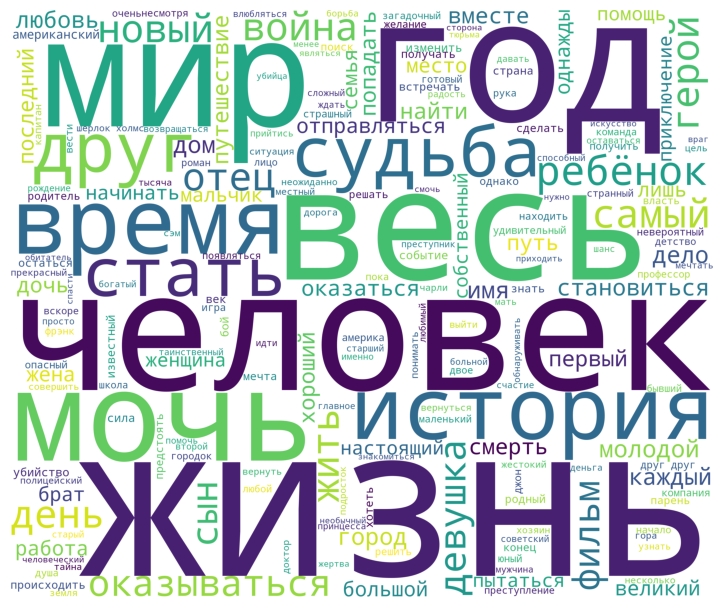

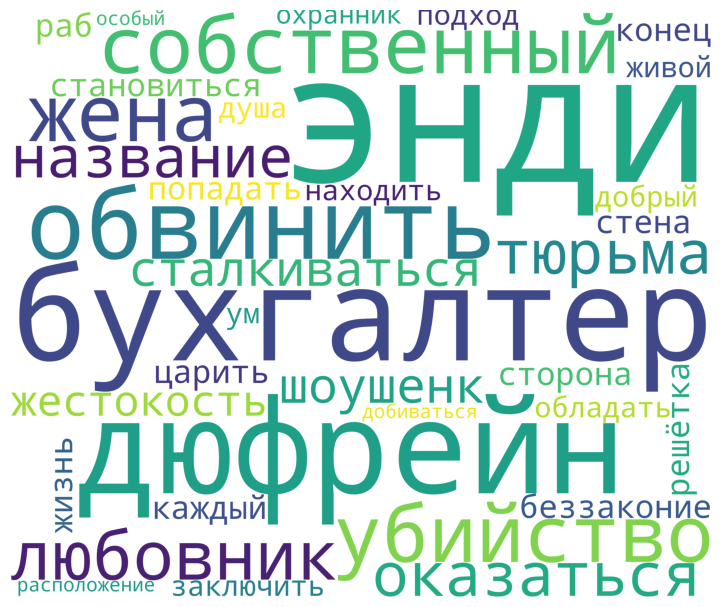

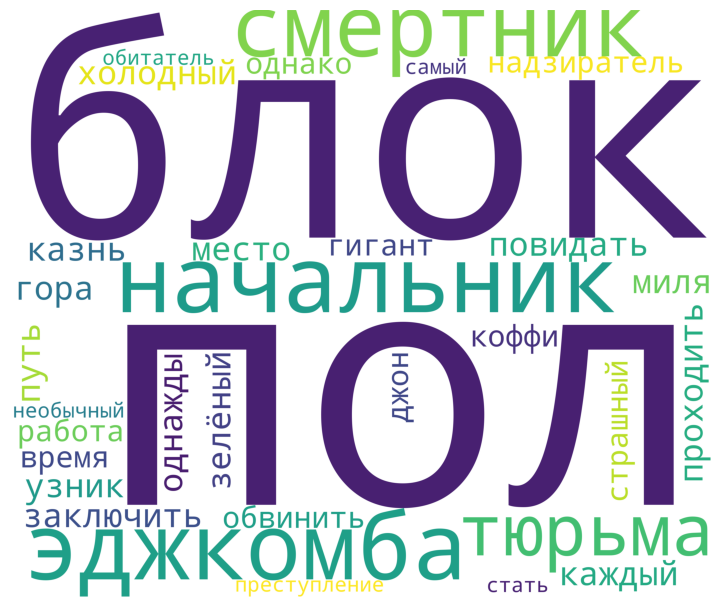

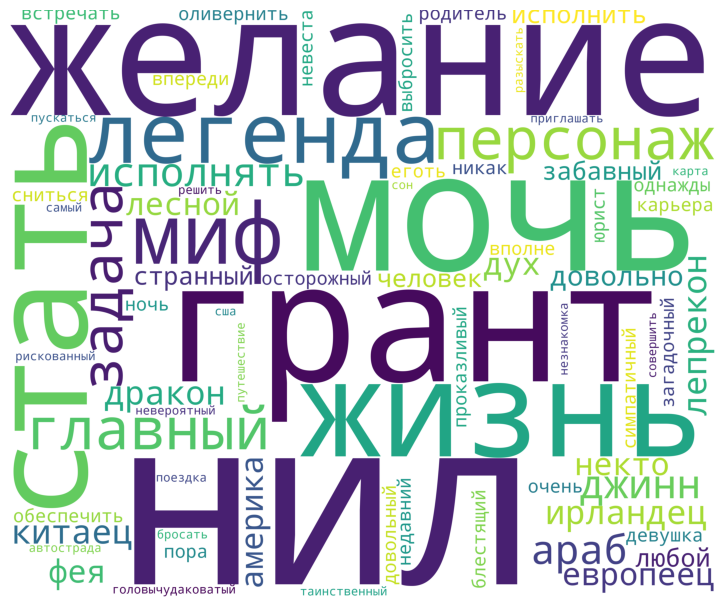

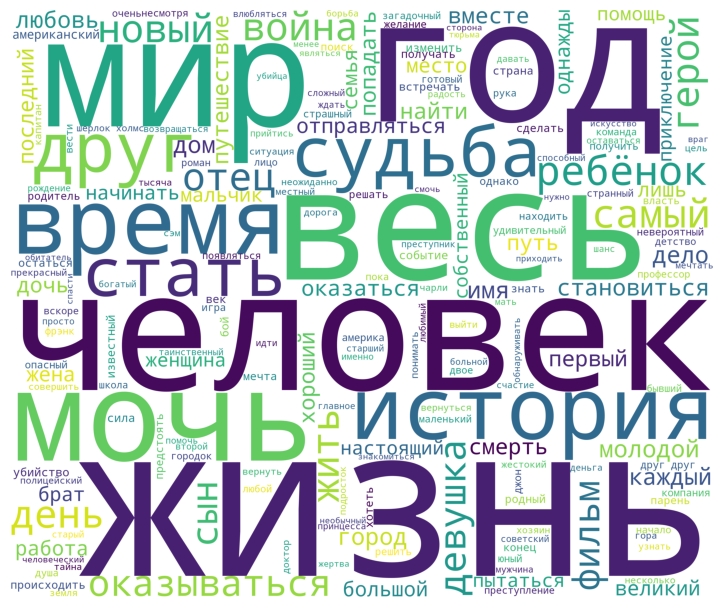

In [101]:
corpus = get_corpus(df['tokenize_text'].values)
procWordCloud = get_wordCloud(corpus)

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)
plt.show()

In [36]:
# Получение облака слов
def get_wordCloud2(corpus):
    wordCloud = WordCloud(background_color='white',
                              stopwords=STOPWORDS,
                              width=3000,
                              height=2500,
                              max_words=200,
                              random_state=42
                         ).generate(corpus)
    return wordCloud

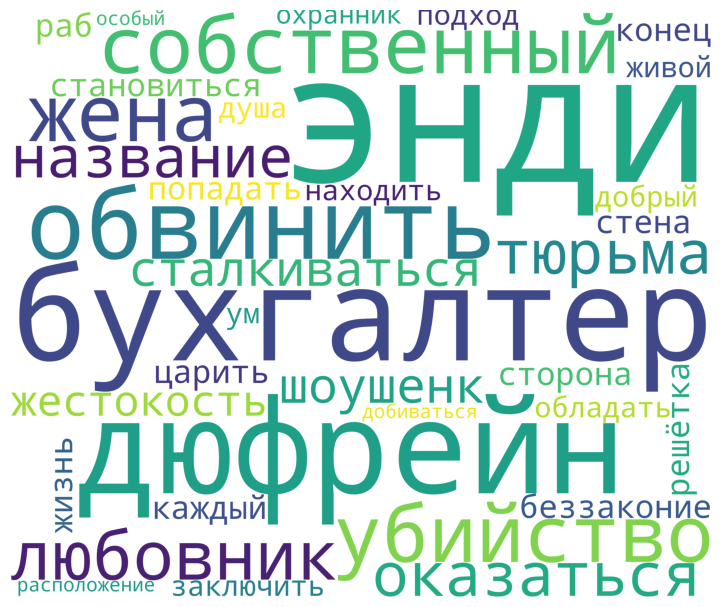

In [102]:
corpus = df['tokenize_text'][0]
procWordCloud = get_wordCloud2(corpus)

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)
plt.show()

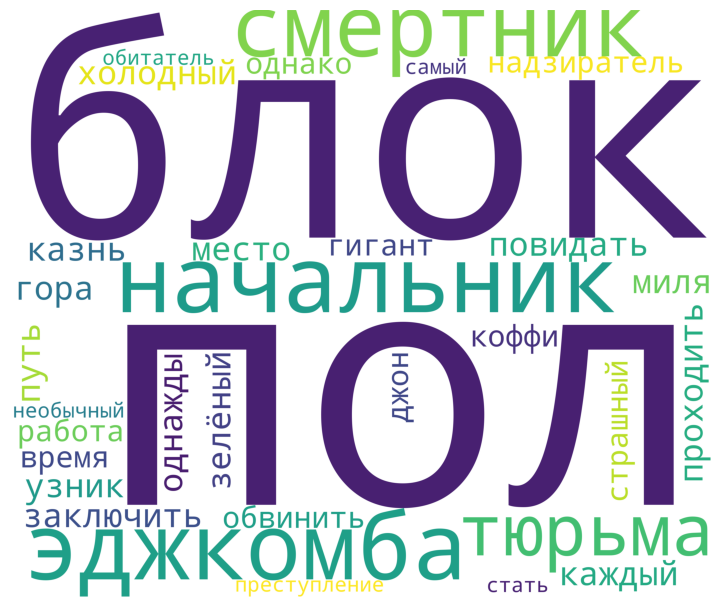

In [103]:
corpus = df['tokenize_text'][1]
procWordCloud = get_wordCloud2(corpus)

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)
plt.show()

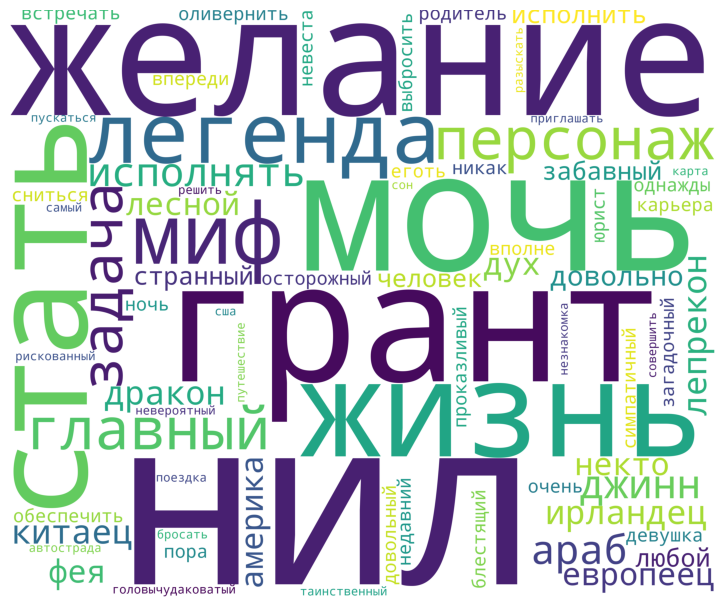

In [104]:
corpus = df['tokenize_text'][200]
procWordCloud = get_wordCloud2(corpus)

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)
plt.show()

In [40]:
import re
from collections import Counter

def remove_most_common_words(text, num_words=10):
   
    words = re.findall(r"\b[a-zA-Zа-яА-ЯёЁ]+\b", text.lower())
    
    word_counts = Counter(words)
    
    most_common = [word for word, count in word_counts.most_common(num_words)]

    #print(word_counts)
    
    pattern = re.compile(r"\b(" + "|".join(map(re.escape, most_common)) + r")\b", flags=re.IGNORECASE)
    cleaned_text = pattern.sub("", text)
    
    cleaned_text = re.sub(r"\s+", " ", cleaned_text).strip()

    return cleaned_text


In [41]:
df['tokenize_text'][0]

'бухгалтер энди дюфрейн обвинить убийство собственный жена любовник оказаться тюрьма название шоушенк сталкиваться жестокость беззаконие царить сторона решётка каждый попадать стена становиться раб конец жизнь энди обладать живой ум добрый душа находить подход заключить охранник добиваться особый расположение'

In [42]:
cleaned_text = remove_most_common_words(df['tokenize_text'][0], 5)
print("Очищенный текст:", cleaned_text)

Очищенный текст: собственный жена любовник оказаться тюрьма название шоушенк сталкиваться жестокость беззаконие царить сторона решётка каждый попадать стена становиться раб конец жизнь обладать живой ум добрый душа находить подход заключить охранник добиваться особый расположение


In [43]:
cleaned_text = remove_most_common_words(df['tokenize_text'][200], 5)
print("Очищенный текст:", cleaned_text)

Очищенный текст: легенда миф персонаж главный задача исполнять араб джинн ирландец лепрекон китаец дракон европеец фея лесной дух америка некто довольно странный забавный человек исполнить любой осторожный очень проказливый еготь встречать однажды оливернить вполне довольный обеспечить родитель симпатичный невеста впереди блестящий карьера юрист недавний пора ночь стать сниться загадочный девушка никак выбросить головычудаковатый приглашать совершить поездка таинственный автострада 60 карта сша бросать пускаться самый невероятный рискованный путешествие решить стать разыскать незнакомка сон


In [44]:
df['tokenize_text2'] = [remove_most_common_words(text, 5) for text in df['tokenize_text']]

In [45]:
df.head()

,rating,movie,year,country,rating_ball,overview,director,screenwriter,actors,url_logo,prep_text,text_lemm,tokenize_text,tokenize_text2
0,0,Побег из Шоушенка,1994,США,9.111,Бухгалтер Энди Дюфрейн обвинён в убийстве собс...,Фрэнк Дарабонт,Фрэнк Дарабонт; Стивен Кинг,Тим Роббинс; Морган Фриман; Боб Гантон; Уильям...,'https://st.kp.yandex.net/images/film_iphone/i...,бухгалтер энди дюфрейн обвинён в убийстве собс...,бухгалтер энди дюфрейн обвинить в убийство соб...,бухгалтер энди дюфрейн обвинить убийство собст...,собственный жена любовник оказаться тюрьма наз...
1,1,Зеленая миля,1999,США,9.062,Пол Эджкомб — начальник блока смертников в тюр...,Фрэнк Дарабонт,Фрэнк Дарабонт; Стивен Кинг,Том Хэнкс; Дэвид Морс; Бонни Хант; Майкл Кларк...,'https://st.kp.yandex.net/images/film_iphone/i...,пол эджкомб начальник блока смертников в тюр...,пол эджкомба начальник блок смертник в тюрьма ...,пол эджкомба начальник блок смертник тюрьма « ...,тюрьма « холодный гора » каждый узник однажды ...
2,2,Форрест Гамп,1994,США,8.913,От лица главного героя Форреста Гампа; слабоум...,Роберт Земекис,Эрик Рот; Уинстон Грум,Том Хэнкс; Робин Райт; Салли Филд; Гэри Синиз;...,'https://st.kp.yandex.net/images/film_iphone/i...,от лица главного героя форреста гампа слабоумн...,от лицо главное герой форрест гампа слабоумный...,лицо главное герой форрест гампа слабоумный бе...,слабоумный безобидный человек благородный откр...
3,3,Список Шиндлера,1993,США,8.817,Фильм рассказывает реальную историю загадочног...,Стивен Спилберг,Стивен Зеллиан; Томас Кенилли,Лиам Нисон; Бен Кингсли; Рэйф Файнс; Кэролайн ...,'https://st.kp.yandex.net/images/film_iphone/i...,фильм рассказывает реальную историю загадочног...,фильм рассказывать реальный история загадочный...,фильм рассказывать реальный история загадочный...,оскар шиндлера член нацистский партия преуспев...
4,4,1+1,2011,Франция,8.807,Пострадав в результате несчастного случая; бог...,Оливье Накаш; Эрик Толедано,Оливье Накаш; Филипп Поццо ди Борго; Эрик Т...,Франсуа Клюзе; Омар Си; Анн Ле Ни; Одри Флеро;...,'https://st.kp.yandex.net/images/film_iphone/i...,пострадав в результате несчастного случая бога...,пострадать в результат несчастный случай богат...,пострадать результат несчастный случай богатый...,несчастный случай богатый нанимать помощник че...


In [46]:
df['tokenize_text2'][0]

'собственный жена любовник оказаться тюрьма название шоушенк сталкиваться жестокость беззаконие царить сторона решётка каждый попадать стена становиться раб конец жизнь обладать живой ум добрый душа находить подход заключить охранник добиваться особый расположение'

In [47]:
df['tokenize_text2'][200]

'легенда миф персонаж главный задача исполнять араб джинн ирландец лепрекон китаец дракон европеец фея лесной дух америка некто довольно странный забавный человек исполнить любой осторожный очень проказливый еготь встречать однажды оливернить вполне довольный обеспечить родитель симпатичный невеста впереди блестящий карьера юрист недавний пора ночь стать сниться загадочный девушка никак выбросить головычудаковатый приглашать совершить поездка таинственный автострада 60 карта сша бросать пускаться самый невероятный рискованный путешествие решить стать разыскать незнакомка сон'

In [48]:
df['tokenize_text2'][3]

'оскар шиндлера член нацистский партия преуспевать фабрикант спасти время второй мировой война 1200 еврей'

In [49]:
df['tokenize_text'][3]

'фильм рассказывать реальный история загадочный оскар шиндлера член нацистский партия преуспевать фабрикант спасти время второй мировой война 1200 еврей'

In [50]:
df['overview'][3]

'Фильм рассказывает реальную историю загадочного Оскара Шиндлера; члена нацистской партии; преуспевающего фабриканта; спасшего во\xa0время Второй мировой войны почти 1200 евреев.'

# Векторизация текстовых данных

### Bag of words

In [51]:
vectorizer = CountVectorizer()
count_matrix1 = vectorizer.fit(df['tokenize_text2'])

In [52]:
len(vectorizer.vocabulary_)

4443

In [53]:
print(vectorizer.vocabulary_)

{'собственный': 3586, 'жена': 1056, 'любовник': 1702, 'оказаться': 2298, 'тюрьма': 3959, 'название': 1946, 'шоушенк': 4350, 'сталкиваться': 3727, 'жестокость': 1068, 'беззаконие': 219, 'царить': 4229, 'сторона': 3763, 'решётка': 3294, 'каждый': 1383, 'попадать': 2760, 'стена': 3748, 'становиться': 3728, 'раб': 3143, 'конец': 1504, 'жизнь': 1078, 'обладать': 2210, 'живой': 1070, 'ум': 4029, 'добрый': 943, 'душа': 1019, 'находить': 2002, 'подход': 2683, 'заключить': 1137, 'охранник': 2462, 'добиваться': 934, 'особый': 2358, 'расположение': 3231, 'холодный': 4208, 'гора': 766, 'узник': 4010, 'однажды': 2288, 'проходить': 3094, 'зелёный': 1217, 'миля': 1819, 'путь': 3133, 'место': 1797, 'казнь': 1387, 'повидать': 2612, 'надзиратель': 1938, 'время': 581, 'работа': 3144, 'однако': 2289, 'гигант': 724, 'джон': 915, 'коффи': 1544, 'обвинить': 2194, 'страшный': 3774, 'преступление': 2919, 'стать': 3747, 'самый': 3377, 'необычный': 2093, 'обитатель': 2208, 'слабоумный': 3509, 'безобидный': 225, 

In [54]:
vectorizer = CountVectorizer(analyzer='word', stop_words=russian_stopwords, ngram_range=(1, 3), min_df=2)
count_matrix = vectorizer.fit_transform(df['tokenize_text'])

In [55]:
count_matrix.shape

(250, 1849)

In [56]:
vectorizer.get_feature_names_out()[160:200]

array(['вместе', 'вместо', 'внедрить', 'внезапно', 'внешний', 'внимание',
       'вновь', 'внутренний', 'вода', 'воевать', 'военный',
       'возвращаться', 'возвращаться домой', 'возглавлять', 'воздушный',
       'возможность', 'возраст', 'воин', 'воинственный', 'война',
       'войско', 'вокруг', 'волос', 'волшебник', 'волшебник гэндальф',
       'волшебный', 'волшебство', 'воля', 'воля судьба', 'воплощение',
       'вор', 'воробей', 'восемь', 'восемь год', 'воспитывать',
       'воспользоваться', 'воссоздать', 'восточный', 'вотвота', 'впадать'],
      dtype=object)

In [57]:
print(count_matrix)

  (0, 1835)	2
  (0, 918)	1
  (0, 1666)	1
  (0, 1496)	1
  (0, 442)	1
  (0, 958)	1
  (0, 1659)	1
  (0, 817)	1
  (0, 1552)	1
  (0, 450)	1
  (0, 47)	1
  (0, 1769)	1
  (0, 1574)	1
  (0, 1376)	1
  (0, 587)	1
  (0, 1133)	1
  (0, 1568)	1
  (0, 1553)	1
  (0, 1323)	1
  (0, 634)	1
  (0, 454)	1
  (0, 923)	1
  (0, 451)	1
  (0, 1700)	1
  (0, 395)	1
  :	:
  (249, 208)	1
  (249, 579)	1
  (249, 347)	1
  (249, 295)	1
  (249, 1069)	1
  (249, 1095)	1
  (249, 1601)	1
  (249, 247)	1
  (249, 80)	1
  (249, 102)	1
  (249, 1577)	1
  (249, 34)	1
  (249, 417)	1
  (249, 890)	1
  (249, 227)	1
  (249, 354)	1
  (249, 860)	1
  (249, 969)	1
  (249, 1253)	1
  (249, 670)	1
  (249, 479)	1
  (249, 228)	1
  (249, 372)	1
  (249, 1146)	1
  (249, 1602)	1


### TF-IDF

In [58]:
tfidf_vectorizer = TfidfVectorizer(max_df=0.8, max_features=10000,
                                 min_df=0.01, stop_words=russian_stopwords,
                                 ngram_range=(1,3))

In [59]:
%%time
tfidf_matrix = tfidf_vectorizer.fit_transform(df['tokenize_text'])

CPU times: total: 46.9 ms
Wall time: 58 ms


In [60]:
tfidf_matrix.shape

(250, 911)

In [61]:
print(tfidf_matrix)

  (0, 458)	0.2630800429428584
  (0, 819)	0.2042879183234777
  (0, 730)	0.20083414594480656
  (0, 220)	0.19758982548926554
  (0, 473)	0.18889264154676186
  (0, 814)	0.23792784664285482
  (0, 761)	0.2750215473409031
  (0, 226)	0.2750215473409031
  (0, 772)	0.23792784664285482
  (0, 293)	0.19453099880019
  (0, 555)	0.19453099880019
  (0, 762)	0.1837921269918548
  (0, 314)	0.22088582768990303
  (0, 229)	0.11606012006367492
  (0, 460)	0.2450737655050022
  (0, 227)	0.22088582768990303
  (0, 189)	0.2533231234195707
  (0, 211)	0.22088582768990303
  (0, 415)	0.2162294227215224
  (0, 240)	0.2630800429428584
  (1, 458)	0.2576693336044822
  (1, 814)	0.2330344369896952
  (1, 293)	0.1905301225648138
  (1, 240)	0.2576693336044822
  (1, 418)	0.26936523970993886
  :	:
  (248, 668)	0.2620644458307902
  (248, 81)	0.2506855420222809
  (248, 872)	0.22071215547154077
  (248, 675)	0.22671834218459982
  (248, 821)	0.24138830065116548
  (248, 599)	0.2506855420222809
  (248, 238)	0.5013710840445618
  (248, 687)

In [62]:
tfidf_vectorizer.get_feature_names_out()[150:160]

array(['городок', 'готовиться', 'готовый', 'грабитель', 'грабёж',
       'гражданин', 'гражданский', 'гражданский война', 'грандиозный',
       'грозить'], dtype=object)

# Тематическое моделирование

Тематическое моделирование позволяет выделять из текстов темы, связанные с определенными множествами слов, и затем смотреть, с какой вероятностью тексты соотносятся с этими темами. 

Библиотека **gensim**. Это популярная открытая библиотека для тематического моделирования, в которой есть нужная модель — LDA (Латентном размещении Дирихле (LDA)). Затем следует создать словарь для тематического моделирования из лемматизированного текста. 

После создания словаря лучше всего отфильтровать те слова, которые встречаются в слишком большом количестве текстов, и те, которые встречаются слишком редко. Для этого есть метод filter_extremes, который принимает в себя аргументы no_above (только слова, которые встречаются не более чем в указанной доле текстов) и no_below (слова, которые встречаются не менее чем в указанном количестве текстов). 

После удаления лишних слов словарь лучше всего ужать в размерах, убрав пропуски с помощью метода compactify.

In [63]:
import gensim

In [64]:
def tokenize2(text):
    t = word_tokenize(text)
    tokens = [token for token in t if token not in russian_stopwords]
    return tokens

In [65]:
df['tokenize_text3'] = [tokenize2(text) for text in df['tokenize_text2']]

In [66]:
df.head()

,rating,movie,year,country,rating_ball,overview,director,screenwriter,actors,url_logo,prep_text,text_lemm,tokenize_text,tokenize_text2,tokenize_text3
0,0,Побег из Шоушенка,1994,США,9.111,Бухгалтер Энди Дюфрейн обвинён в убийстве собс...,Фрэнк Дарабонт,Фрэнк Дарабонт; Стивен Кинг,Тим Роббинс; Морган Фриман; Боб Гантон; Уильям...,'https://st.kp.yandex.net/images/film_iphone/i...,бухгалтер энди дюфрейн обвинён в убийстве собс...,бухгалтер энди дюфрейн обвинить в убийство соб...,бухгалтер энди дюфрейн обвинить убийство собст...,собственный жена любовник оказаться тюрьма наз...,"[собственный, жена, любовник, оказаться, тюрьм..."
1,1,Зеленая миля,1999,США,9.062,Пол Эджкомб — начальник блока смертников в тюр...,Фрэнк Дарабонт,Фрэнк Дарабонт; Стивен Кинг,Том Хэнкс; Дэвид Морс; Бонни Хант; Майкл Кларк...,'https://st.kp.yandex.net/images/film_iphone/i...,пол эджкомб начальник блока смертников в тюр...,пол эджкомба начальник блок смертник в тюрьма ...,пол эджкомба начальник блок смертник тюрьма « ...,тюрьма « холодный гора » каждый узник однажды ...,"[тюрьма, «, холодный, гора, », каждый, узник, ..."
2,2,Форрест Гамп,1994,США,8.913,От лица главного героя Форреста Гампа; слабоум...,Роберт Земекис,Эрик Рот; Уинстон Грум,Том Хэнкс; Робин Райт; Салли Филд; Гэри Синиз;...,'https://st.kp.yandex.net/images/film_iphone/i...,от лица главного героя форреста гампа слабоумн...,от лицо главное герой форрест гампа слабоумный...,лицо главное герой форрест гампа слабоумный бе...,слабоумный безобидный человек благородный откр...,"[слабоумный, безобидный, человек, благородный,..."
3,3,Список Шиндлера,1993,США,8.817,Фильм рассказывает реальную историю загадочног...,Стивен Спилберг,Стивен Зеллиан; Томас Кенилли,Лиам Нисон; Бен Кингсли; Рэйф Файнс; Кэролайн ...,'https://st.kp.yandex.net/images/film_iphone/i...,фильм рассказывает реальную историю загадочног...,фильм рассказывать реальный история загадочный...,фильм рассказывать реальный история загадочный...,оскар шиндлера член нацистский партия преуспев...,"[оскар, шиндлера, член, нацистский, партия, пр..."
4,4,1+1,2011,Франция,8.807,Пострадав в результате несчастного случая; бог...,Оливье Накаш; Эрик Толедано,Оливье Накаш; Филипп Поццо ди Борго; Эрик Т...,Франсуа Клюзе; Омар Си; Анн Ле Ни; Одри Флеро;...,'https://st.kp.yandex.net/images/film_iphone/i...,пострадав в результате несчастного случая бога...,пострадать в результат несчастный случай богат...,пострадать результат несчастный случай богатый...,несчастный случай богатый нанимать помощник че...,"[несчастный, случай, богатый, нанимать, помощн..."


In [67]:
gensim_dictionary = gensim.corpora.Dictionary(df['tokenize_text3'])
gensim_dictionary.filter_extremes(no_above=0.1, no_below=20)
gensim_dictionary.compactify()

In [68]:
corpus = [gensim_dictionary.doc2bow(text) 
          for text in df['tokenize_text3']]

In [69]:
corpus

[[(0, 1)],
 [],
 [(0, 1), (1, 1)],
 [(1, 1)],
 [(2, 1)],
 [],
 [],
 [(0, 1), (3, 1), (4, 1)],
 [],
 [],
 [(1, 1)],
 [(0, 1)],
 [(5, 1)],
 [],
 [(5, 1)],
 [],
 [(6, 1)],
 [],
 [(5, 1)],
 [(0, 1), (7, 1)],
 [(2, 1)],
 [(2, 1), (8, 1)],
 [(4, 1), (5, 1), (8, 1)],
 [],
 [(5, 1)],
 [],
 [(5, 1)],
 [(3, 1), (8, 1)],
 [(8, 1)],
 [(3, 1)],
 [(0, 1), (4, 1)],
 [],
 [],
 [(7, 1)],
 [],
 [],
 [],
 [(4, 1), (7, 1)],
 [],
 [(2, 1)],
 [],
 [(3, 2), (4, 1), (8, 1)],
 [],
 [(0, 1)],
 [(8, 1)],
 [],
 [(7, 1)],
 [],
 [(1, 1)],
 [],
 [(3, 1), (6, 1)],
 [],
 [],
 [(2, 1), (8, 1)],
 [(2, 1)],
 [(1, 1)],
 [(5, 1), (6, 1), (7, 1)],
 [(1, 1), (2, 1), (6, 1)],
 [(4, 1)],
 [],
 [(3, 2), (7, 1)],
 [(0, 1)],
 [],
 [(8, 1)],
 [(5, 1), (6, 1)],
 [(3, 1)],
 [(2, 1), (6, 2)],
 [],
 [(1, 1), (8, 1)],
 [(0, 1)],
 [],
 [(2, 1)],
 [(6, 1)],
 [],
 [],
 [(6, 1), (8, 1)],
 [(1, 1), (2, 1), (8, 1)],
 [],
 [],
 [],
 [],
 [],
 [(6, 1)],
 [],
 [],
 [(1, 1), (6, 1)],
 [],
 [(6, 1)],
 [(8, 1)],
 [(0, 1), (2, 1)],
 [],
 [(3, 1), (

In [70]:
lda_20 = gensim.models.LdaMulticore(corpus, 
                                 num_topics=5, 
                                 id2word=gensim_dictionary, 
                                 passes=10, random_state=6457)

In [71]:
lda_20.print_topics()

[(0,
  '0.490*"судьба" + 0.477*"герой" + 0.006*"оказываться" + 0.006*"война" + 0.004*"имя" + 0.004*"молодой" + 0.004*"друг" + 0.004*"становиться" + 0.004*"день"'),
 (1,
  '0.535*"оказываться" + 0.417*"война" + 0.013*"друг" + 0.008*"молодой" + 0.006*"имя" + 0.006*"становиться" + 0.005*"судьба" + 0.005*"герой" + 0.005*"день"'),
 (2,
  '0.358*"молодой" + 0.333*"друг" + 0.286*"имя" + 0.005*"день" + 0.004*"судьба" + 0.004*"война" + 0.003*"герой" + 0.003*"оказываться" + 0.003*"становиться"'),
 (3,
  '0.904*"становиться" + 0.030*"оказываться" + 0.012*"имя" + 0.009*"судьба" + 0.009*"друг" + 0.009*"война" + 0.009*"герой" + 0.009*"день" + 0.009*"молодой"'),
 (4,
  '0.763*"день" + 0.153*"война" + 0.028*"друг" + 0.017*"судьба" + 0.009*"имя" + 0.008*"молодой" + 0.008*"оказываться" + 0.008*"становиться" + 0.007*"герой"')]

In [73]:
pip install pyLDAvis

Defaulting to user installation because normal site-packages is not writeable
  Using cached pyLDAvis-3.4.1-py3-none-any.whl.metadata (4.2 kB)
  Using cached funcy-2.0-py2.py3-none-any.whl.metadata (5.9 kB)
Using cached pyLDAvis-3.4.1-py3-none-any.whl (2.6 MB)
Using cached funcy-2.0-py2.py3-none-any.whl (30 kB)
Note: you may need to restart the kernel to use updated packages.


In [74]:
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis

In [75]:
vis_20 = gensimvis.prepare(lda_20, corpus, gensim_dictionary)

In [76]:
pyLDAvis.enable_notebook()

In [77]:
vis_20

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
2     -0.017580  0.360114       1        1  29.110177
0     -0.340768 -0.174344       2        1  22.493369
1      0.229913 -0.140654       3        1  18.945868
4      0.187228 -0.095090       4        1  15.676600
3     -0.058794  0.049973       5        1  13.773986, topic_info=          Term       Freq      Total Category  logprob  loglift
0  становиться  25.000000  25.000000  Default   9.0000   9.0000
8         день  24.000000  24.000000  Default   8.0000   8.0000
7  оказываться  21.000000  21.000000  Default   7.0000   7.0000
5        герой  22.000000  22.000000  Default   6.0000   6.0000
6       судьба  23.000000  23.000000  Default   5.0000   5.0000
1        война  21.000000  21.000000  Default   4.0000   4.0000
2      молодой  21.000000  21.000000  Default   3.0000   3.0000
3         друг  21.000000  21.000000  Default   2.0000   2.0000
4          имя  17.000000  17.000000  Default   1.0000   1.0000
2      молодой  20.968224  21.936439   Topic1  -1.0262   1.1889
4          имя  16.754198  17.779761   Topic1  -1.2506   1.1747
3         друг  19.474935  21.309298   Topic1  -1.1001   1.1441
8         день   0.308960  24.963446   Topic1  -5.2438  -3.1579
6       судьба   0.244058  23.393737   Topic1  -5.4796  -3.3287
1        война   0.207064  21.424321   Topic1  -5.6440  -3.4052
7  оказываться   0.189521  21.901318   Topic1  -5.7325  -3.5157
5        герой   0.191925  22.432967   Topic1  -5.7199  -3.5271
0  становиться   0.172567  25.858716   Topic1  -5.8262  -3.7755
5        герой  21.567168  22.432967   Topic2  -0.7402   1.4526
6       судьба  22.145212  23.393737   Topic2  -0.7137   1.4371
7  оказываться   0.281199  21.901318   Topic2  -5.0800  -2.8633
1        война   0.264091  21.424321   Topic2  -5.1428  -2.9040
4          имя   0.199375  17.779761   Topic2  -5.4239  -2.9987
2      молодой   0.196307  21.936439   Topic2  -5.4394  -3.2243
3         друг   0.189687  21.309298   Topic2  -5.4737  -3.2296
0  становиться   0.189372  25.858716   Topic2  -5.4754  -3.4247
8         день   0.179262  24.963446   Topic2  -5.5303  -3.4444
7  оказываться  20.358294  21.901318   Topic3  -0.6262   1.5905
1        война  15.882420  21.424321   Topic3  -0.8745   1.3643
3         друг   0.511520  21.309298   Topic3  -4.3101  -2.0659
2      молодой   0.288234  21.936439   Topic3  -4.8837  -2.6685
4          имя   0.218745  17.779761   Topic3  -5.1596  -2.7343
6       судьба   0.209023  23.393737   Topic3  -5.2050  -3.0542
5        герой   0.199387  22.432967   Topic3  -5.2522  -3.0595
0  становиться   0.214640  25.858716   Topic3  -5.1785  -3.1279
8         день   0.198932  24.963446   Topic3  -5.2545  -3.1686
8         день  24.031418  24.963446   Topic4  -0.2709   1.8150
1        война   4.820288  21.424321   Topic4  -1.8775   0.3613
3         друг   0.880340  21.309298   Topic4  -3.5778  -1.3336
6       судьба   0.536910  23.393737   Topic4  -4.0722  -1.9214
4          имя   0.283692  17.779761   Topic4  -4.7102  -2.2849
2      молодой   0.245491  21.936439   Topic4  -4.8548  -2.6396
7  оказываться   0.241157  21.901318   Topic4  -4.8726  -2.6559
5        герой   0.229610  22.432967   Topic4  -4.9217  -2.7289
0  становиться   0.241061  25.858716   Topic4  -4.8730  -2.8224
0  становиться  25.041076  25.858716   Topic5  -0.1004   1.9503
7  оказываться   0.831147  21.901318   Topic5  -3.5059  -1.2891
4          имя   0.323751  17.779761   Topic5  -4.4487  -2.0235
3         друг   0.252815  21.309298   Topic5  -4.6960  -2.4519
1        война   0.250458  21.424321   Topic5  -4.7054  -2.4666
6       судьба   0.258533  23.393737   Topic5  -4.6736  -2.5228
5        герой   0.244877  22.432967   Topic5  -4.7279  -2.5351
2      молодой   0.238182  21.936439   Topic5  -4.7556  -2.5405
8         день   0.244873  24.963446   Topic5  -4.7279  -2.6420, token_table=      Topic      Freq         Term
term       

LDA - это метод машинного обучения, который используется для анализа тематической структуры в больших наборах документов. Который использует модель вероятности, чтобы определить, какие темы присутствуют в каждом документе, и какие слова связаны с каждой темой. LDA может быть полезен в случаях, когда нужно опредлить тематическую структуру в большом наборе документов, таких как статьи и т.д.

CoherenceModel — это класс из библиотеки Gensim, который используется для оценки качества тематической модели (например, LDA) с помощью метрики когерентности (coherence). Когерентность измеряет, насколько хорошо темы, выявленные моделью, соответствуют человеческому восприятию. Чем выше когерентность, тем более интерпретируемыми и осмысленными являются темы.

In [78]:
from gensim.models import CoherenceModel

coherence_model = CoherenceModel(model=lda_20,
                                 texts=df['tokenize_text3'],
                                 dictionary=gensim_dictionary,
                                 coherence="c_v")

coherence_value = coherence_model.get_coherence()
print(f"Когерентность модели: {coherence_value}")

Когерентность модели: 0.38133087605274474


In [473]:
from sklearn.decomposition import LatentDirichletAllocation

In [481]:
# создание модели LDA
lda_model = LatentDirichletAllocation(n_components=6, random_state=0)
lda_model.fit(count_matrix)

# вывод топ слов для каждой темы
for i, topic in enumerate(lda_model.components_):
    print(f"Topic {i}: {', '.join([vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

Topic 0: жизнь, человек, мир, год, время, самый, отец, фильм, стать, ребёнок
Topic 1: год, жизнь, друг, человек, весь, мочь, ещё, шерлок холмс, холмс, шерлок
Topic 2: друг, весь, джек, история, мир, жизнь, элизабет, попадать, капитан, компания
Topic 3: мир, год, жизнь, герой, время, весь, мочь, должный, история, поиск
Topic 4: жизнь, стать, друг, человек, каждый, год, новый, жить, отец, мир
Topic 5: жизнь, человек, мочь, судьба, год, молодой, время, война, убийство, путешествие


In [477]:
lda_model = LatentDirichletAllocation(learning_method='online', random_state=5, n_jobs=-1, n_components=11)
lda_model.fit(count_matrix)

LatentDirichletAllocation(learning_method='online', n_components=11, n_jobs=-1,
                          random_state=5)

In [485]:
#датафрейм для ключевых слов каждой темы
topic_keywords = pd.DataFrame()
for i,topic in enumerate(lda_model.components_):
    topic_keywords[f'Topic {i + 1}'] = [vectorizer.get_feature_names_out()[i] for i in topic.argsort()[-50:]]
topic_keywords

,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6
0,найти,заставлять,неприятность,волшебник,друг друг,дарт вейдёр
1,взрослый,должный,сильный,найти,доля,дарт
2,дэнни,мафия,приключение,задание,война,воин
3,изменить,двое,появляться,лишь,карьера,становиться
4,американский,давать,схватка,предстоять,тайно,парень
5,жестокий,становиться,ситуация,опасность,зелёный,домой
6,знать,вместе,воробей,мечта,лейтенант,слишком
7,молодой,несмотря,джек воробей,подросток,сара,последний
8,событие,родный,война,получить,немой,сила
9,первый,герой,смертельный,улица,оказываться,тысяча


NMF - это метод машинного обучения, который используется для разложения матрицы на две с неотрицательными элементами. Он может быть полезен в случаях, когда нужно найти скрытые признаки в данных, таких как тексты и т.д. NMF может использоваться в различных областях, таких как обработка изображений, текстовый анализ и т.д

In [79]:
from sklearn.decomposition import NMF

In [80]:
# создание модели NMF
nmf_model = NMF(n_components=10, random_state=0)
nmf_model.fit(tfidf_matrix)

# вывод топ слов для каждой темы
for i, topic in enumerate(nmf_model.components_):
    print(f"Topic {i}: {', '.join([tfidf_vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

Topic 0: человек, мочь, жить, девушка, мир, судьба, путешествие, жизнь, весь, изменить
Topic 1: шерлок холмс, холмс, шерлок, ватсон, доктор, доктор ватсон, схватка, убийца, сыщик, угроза
Topic 2: война, мировой, мировой война, второй мировой, второй мировой война, второй, лагерь, время, семья, время второй
Topic 3: марти, машина, время, подросток, машина время, попадать, док, помощь, приключение, далёкий
Topic 4: друг, друг друг, стать, сильный, любовь, однажды, удивительный, решать, тело, год
Topic 5: отец, сын, брат, дочь, работа, роман, большой, старший, сэм, дело
Topic 6: джек, элизабет, уилла, капитан, джек воробей, воробей, проклятие, вечный, приключение, свет
Topic 7: ребёнок, мир, родитель, мальчик, дом, малыш, актёр, дорога, жизнь, весь
Topic 8: жизнь, год, герой, фильм, мечта, каждый, стать, тысяча, известный, знаменитый
Topic 9: бой, новый, год, любовь, кольцо, родный, земля, остаться, война, джон


C:\Anaconda2\Lib\site-packages\sklearn\decomposition\_nmf.py:1759: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


In [81]:
# создание модели NMF
nmf_model = NMF(n_components=5, random_state=0)
nmf_model.fit(tfidf_matrix)

# вывод топ слов для каждой темы
for i, topic in enumerate(nmf_model.components_):
    print(f"Topic {i}: {', '.join([tfidf_vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

Topic 0: ребёнок, мир, мочь, отец, человек, весь, девушка, жизнь, дело, жить
Topic 1: холмс, шерлок, шерлок холмс, ватсон, доктор, доктор ватсон, схватка, убийца, сыщик, угроза
Topic 2: друг, друг друг, стать, любовь, сильный, год, новый, девушка, однажды, удивительный
Topic 3: жизнь, год, время, герой, фильм, век, попадать, каждый, мечта, машина
Topic 4: война, бой, сын, мировой, судьба, последний, мировой война, человек, время, второй мировой


C:\Anaconda2\Lib\site-packages\sklearn\decomposition\_nmf.py:1759: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


LSA - это метод машинного обучения, который используется для анализа структуры в больших наборах текстовых данных. Он использует матричные вычисления для определения близости между словами и документами. LSA может быть полезен в случаях, когда вы хотите определить структуру в большом наборе текстовых данных, таких как статьи, отчеты и т.д.

In [82]:
from sklearn.decomposition import TruncatedSVD

In [83]:
# создание модели LSA
lsa_model = TruncatedSVD(n_components=5, random_state=0)
lsa_model.fit(tfidf_matrix)

# вывод топ слов для каждой темы
for i, topic in enumerate(lsa_model.components_):
    print(f"Topic {i}: {', '.join([tfidf_vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

Topic 0: жизнь, год, человек, друг, мочь, весь, мир, время, судьба, стать
Topic 1: друг, шерлок холмс, холмс, шерлок, ватсон, доктор, доктор ватсон, схватка, друг друг, лондон
Topic 2: друг, друг друг, девушка, жить, удивительный, стать, однажды, любовь, странный, жизнь
Topic 3: время, марти, век, год, машина, история, попадать, машина время, приключение, герой
Topic 4: друг, сын, война, отец, новый, любовь, капитан, бой, джек, время


## Кластеризация

In [84]:
num_clusters = 5

# Метод к-средних - KMeans
from sklearn.cluster import KMeans
km = KMeans(n_clusters=num_clusters)

In [85]:
%%time
km.fit(tfidf_matrix)

CPU times: total: 156 ms
Wall time: 172 ms


KMeans(n_clusters=5)

In [86]:
idx = km.fit(tfidf_matrix)
clusters = km.labels_.tolist()

In [87]:
len(km.labels_)

250

In [88]:
clusters[:10]

[1, 4, 3, 2, 0, 4, 3, 1, 4, 0]

In [89]:
clusterkm = km.labels_.tolist()
df['cluster']= clusterkm

In [90]:
df['cluster'].value_counts()

cluster
3    67
1    56
4    51
2    48
0    28
Name: count, dtype: int64

In [91]:
df[df['cluster']==0]

,rating,movie,year,country,rating_ball,overview,director,screenwriter,actors,url_logo,prep_text,text_lemm,tokenize_text,tokenize_text2,tokenize_text3,cluster
4,4,1+1,2011,Франция,8.807,Пострадав в результате несчастного случая; бог...,Оливье Накаш; Эрик Толедано,Оливье Накаш; Филипп Поццо ди Борго; Эрик Т...,Франсуа Клюзе; Омар Си; Анн Ле Ни; Одри Флеро;...,'https://st.kp.yandex.net/images/film_iphone/i...,пострадав в результате несчастного случая бога...,пострадать в результат несчастный случай богат...,пострадать результат несчастный случай богатый...,несчастный случай богатый нанимать помощник че...,"[несчастный, случай, богатый, нанимать, помощн...",0
9,9,Иван Васильевич меняет профессию,1973,СССР,8.782,Инженер-изобретатель Тимофеев сконструировал м...,Леонид Гайдай,Владлен Бахнов; Леонид Гайдай; Михаил Булгаков,Александр Демьяненко; Юрий Яковлев; Леонид Кур...,'https://st.kp.yandex.net/images/film_iphone/i...,инженеризобретатель тимофеев сконструировал ма...,инженеризобретатель тимофеев сконструировать м...,инженеризобретатель тимофеев сконструировать м...,тимофеев сконструировать время соединить кварт...,"[тимофеев, сконструировать, время, соединить, ...",0
13,13,Криминальное чтиво,1994,США,8.619,Двое бандитов Винсент Вега и Джулс Винфилд вед...,Квентин Тарантино,Квентин Тарантино; Роджер Эвери,Джон Траволта; Сэмюэл Л. Джексон; Брюс Уиллис;...,'https://st.kp.yandex.net/images/film_iphone/i...,двое бандитов винсент вега и джулс винфилд вед...,двое бандит винсент вега и джулс винфилд вести...,двое бандит винсент вега джулс винфилд вести ф...,бандит вега винфилд вести философский беседа п...,"[бандит, вега, винфилд, вести, философский, бе...",0
17,17,Интерстеллар,2014,США,8.591,Когда засуха; пыльные бури и вымирание растени...,Кристофер Нолан,Джонатан Нолан; Кристофер Нолан,Мэттью МакКонахи; Энн Хэтэуэй; Джессика Честей...,'https://st.kp.yandex.net/images/film_iphone/i...,когда засуха пыльные бури и вымирание растений...,когда засуха пыльный буря и вымирание растение...,засуха пыльный буря вымирание растение приводи...,вымирание растение приводить продовольственный...,"[вымирание, растение, приводить, продовольстве...",0
36,36,Остров проклятых,2009,США,8.493,Два американских судебных пристава отправляютс...,Мартин Скорсезе,Лаэта Калогридис; Деннис Лихейн,Леонардо ДиКаприо; Марк Руффало; Бен Кингсли; ...,'https://st.kp.yandex.net/images/film_iphone/i...,два американских судебных пристава отправляютс...,два американский судебный пристав отправляться...,американский судебный пристав отправляться ост...,остров штат массачусетс расследовать исчезнове...,"[остров, штат, массачусетс, расследовать, исче...",0
39,39,Титаник,1997,США,8.365,В первом и последнем плавании шикарного «Титан...,Джеймс Кэмерон,Джеймс Кэмерон,Леонардо ДиКаприо; Кейт Уинслет; Билли Зейн; К...,'https://st.kp.yandex.net/images/film_iphone/i...,в первом и последнем плавании шикарного «титан...,в первый и последний плавание шикарный « титан...,первый последний плавание шикарный « титаник »...,« » встречаться двое пассажир нижний палуба дж...,"[«, », встречаться, двое, пассажир, нижний, па...",0
49,49,Эта замечательная жизнь,1947,США,8.449,Джордж Бейли; владелец кредитной компании в вы...,Фрэнк Капра,Фрэнсис Гудрич; Альберт Хэкетт; Фрэнк Капра...,Джеймс Стюарт; Донна Рид; Лайонел Бэрримор; То...,'https://st.kp.yandex.net/images/film_iphone/i...,джордж бейли владелец кредитной компании в выд...,джордж бейль владелец кредитный компания в выд...,джордж бейль владелец кредитный компания выдум...,компания выдумать американский городок бедфорд...,"[компания, выдумать, американский, городок, бе...",0
57,57,Терминатор 2: Судный день,1991,США,8.309,Прошло более десяти лет с тех пор; как киборг ...,Джеймс Кэмерон,Джеймс Кэмерон; Уильям Уишер мл.,Арнольд Шварценеггер; Линда Хэмилтон; Эдвард Ф...,'https://st.kp.yandex.net/images/film_iphone/i...,прошло более десяти лет с тех пор как киборг и...,пройти более десять год с тот пора как киборг ...,пройти десять год пора киборг 20

In [93]:
df0 = df[df['cluster']==0]

In [94]:
gensim_dictionary = gensim.corpora.Dictionary(df0['tokenize_text3'])

In [95]:
corpus = [gensim_dictionary.doc2bow(text) 
          for text in df0['tokenize_text3']]

In [96]:
lda_5 = gensim.models.LdaMulticore(corpus, 
                                 num_topics=5, 
                                 id2word=gensim_dictionary, 
                                 passes=10, random_state=6457)

In [97]:
lda_5.print_topics()

[(0,
  '0.007*"нанимать" + 0.007*"человек" + 0.007*"пройти" + 0.007*"война" + 0.005*"ас" + 0.005*"дух" + 0.005*"именно" + 0.005*"молодой" + 0.005*"курс" + 0.005*"условие"'),
 (1,
  '0.009*"человек" + 0.006*"решение" + 0.006*"штат" + 0.006*"брат" + 0.006*"поиск" + 0.006*"одновременно" + 0.006*"принять" + 0.003*"находить" + 0.003*"среди" + 0.003*"навсегда"'),
 (2,
  '0.011*"человек" + 0.008*"получить" + 0.004*"решение" + 0.004*"неплохо" + 0.004*"старый" + 0.004*"застенчивый" + 0.004*"место" + 0.004*"отдел" + 0.004*"людмила" + 0.004*"приударить"'),
 (3,
  '0.010*"мир" + 0.007*"»" + 0.007*"«" + 0.007*"считаться" + 0.007*"срок" + 0.004*"компания" + 0.004*"неожиданно" + 0.004*"человек" + 0.004*"молодой" + 0.004*"богатый"'),
 (4,
  '0.009*"волшебник" + 0.006*"весь" + 0.006*"смертельный" + 0.006*"великий" + 0.006*"дракон" + 0.006*"гора" + 0.006*"одинокий" + 0.006*"компания" + 0.006*"гэндальф" + 0.006*"попадать"')]

In [98]:
vis_20 = gensimvis.prepare(lda_5, corpus, gensim_dictionary)

In [99]:
pyLDAvis.enable_notebook()

In [100]:
vis_20

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0     -0.124437 -0.004818       1        1  30.799413
4      0.090458 -0.055822       2        1  20.219760
1     -0.007811 -0.054310       3        1  18.487005
3      0.035725  0.112225       4        1  17.377824
2      0.006065  0.002725       5        1  13.115998, topic_info=             Term      Freq     Total Category  logprob  loglift
24        человек  5.000000  5.000000  Default  30.0000  30.0000
182           мир  3.000000  3.000000  Default  29.0000  29.0000
388     волшебник  2.000000  2.000000  Default  28.0000  28.0000
199      получить  2.000000  2.000000  Default  27.0000  27.0000
510          срок  1.000000  1.000000  Default  26.0000  26.0000
..            ...       ...       ...      ...      ...      ...
329   застенчивый  0.532204  1.488703   Topic5  -5.4941   1.0027
39          место  0.532202  1.524726   Topic5  -5.4941   0.9788
256           сын  0.532106  2.791987   Topic5  -5.4942   0.3737
746       попытка  0.532090  1.621262   Topic5  -5.4943   0.9172
194  отказываться  0.531835  1.621335   Topic5  -5.4948   0.9167

[243 rows x 6 columns], token_table=      Topic      Freq      Term
term                           
677       2  0.924811        13
25        1  0.364152         «
25        2  0.364152         «
25        4  0.364152         «
26        1  0.364150         »
...     ...       ...       ...
133       2  0.468207      штат
133       3  0.468207      штат
722       3  0.941920   шэннона
517       4  0.956792  элизабет
345       5  1.022591      юбка

[271 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 5, 2, 4, 3])